# Automated Brain Tumour Classification and Bounding-Box Localization from MRI Images
### using Machine Learning, Deep Learning and a Genetic Algorithm

Dataset: Figshare brain tumour dataset (Cheng et al.) - 3064 T1-weighted contrast-enhanced MRI
slices from 233 patients. Three tumour types: meningioma (708), glioma (1426), pituitary (930).

**We are doing two things with this data:**

| | Task | Predict | From | Type |
|---|---|---|---|---|
| A | Classification | which of 3 tumour types | the image | supervised, nominal |
| B | Localization | the tumour's bounding box (4 numbers) | the image | supervised, continuous |

Task B is our regression problem. Everything in Unit II applies to it.

The notebook runs in order and each Part builds on the last. Parts 1-3 turn images into a feature
table, Parts 4-5 do regression, Parts 6-9 do classification and clustering, Part 10 is the CNN,
Part 11 collects the numbers we need for the paper.

---
# Part 0 - What we can and cannot do with this data

Each `.mat` file has one struct `cjdata` with five fields:

| Field | What it is |
|---|---|
| `image` | 512x512 MRI slice - **the only input we are allowed** |
| `label` | 1/2/3 tumour type - annotation |
| `tumorBorder` | hand-drawn outline coordinates - annotation |
| `tumorMask` | binary tumour region - annotation |
| `PID` | patient ID (233 unique, ~13 slices each) |

The image is the input. The label, border and mask are all things a radiologist drew by hand, so
they are targets, not inputs. On a new patient they do not exist - that is why we are building a
model at all.

### Picking the regression target

We went through the options before writing any code:

| Idea | Verdict |
|---|---|
| tumour type | valid, but nominal - that is classification, not regression |
| **bounding box from the mask** | **valid, continuous, 4 targets - this is what we use** |
| tumour area from perimeter | **no** - both come from the same mask, so it is a unit conversion, not a prediction |
| tumour area from image texture | fine but redundant, the box already gives us `w x h` |
| patient age / tumour grade | not in the dataset |

The area-from-perimeter idea was our first attempt and it was wrong. For a roughly round region
$A = P^2/4\pi$, so it gets a high R-squared while predicting nothing. It also fails the deployment
test: if we already have the mask to measure the perimeter, we already have the area.

So the rule for the whole notebook: **no feature computed from `tumorMask` or `tumorBorder` is ever
used as an input.** Features come from pixels only.

### Regression on images

The target is the box - the smallest rectangle round the tumour, written as centre and size and
divided by the image dimensions so everything lands in [0,1]:

$$(c_x,\ c_y,\ w,\ h)$$

For the input we turn each image into a fixed-length vector of numbers (Part 2), which makes every
row an ordinary tabular sample. Part 10 does it the other way and lets a CNN learn the features.
Comparing the two is the point of the project.

**Reinforcement learning** (Unit IV) does not apply here - there is no agent, no sequence of
actions and no environment to act on. It is covered in the separate traffic-signal assignment.

---
# Part 1 - Loading the data

Downloads the dataset on Colab and sets everything up. `CONFIG` holds all the settings in one
place.

In [ ]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
EXTRACT_DIR = "/content/data/raw_mat"

if IN_COLAB:
    !pip install h5py scikit-image -q
    if not os.path.isdir(EXTRACT_DIR) or len(os.listdir(EXTRACT_DIR)) == 0:
        !wget -q --show-progress -O /content/figshare.zip "https://ndownloader.figshare.com/articles/1512427/versions/5"
        !mkdir -p /content/figshare_raw && unzip -q /content/figshare.zip -d /content/figshare_raw
        !mkdir -p {EXTRACT_DIR}
        import glob as _g
        for part in sorted(_g.glob("/content/figshare_raw/*.zip")):
            !unzip -q -o {part} -d {EXTRACT_DIR}

CONFIG = {
    "IMG_SIZE": 128,      # images resized to this
    "GRID": 8,            # spatial features use an 8x8 grid
    "SEED": 42,
    "TRAIN_FRAC": 0.8,
    "BRIGHT_PCTL": 95,    # a pixel is "bright" if above this percentile
    "CNN_EPOCHS": 30,
    "GA_POP": 24,
    "GA_GENS": 20,
}
SEED = CONFIG["SEED"]
os.makedirs("cache", exist_ok=True)
os.makedirs("paper", exist_ok=True)   # results tables for the write-up land here
print(CONFIG)

/content/figshare.z 100%[===================>] 838.76M  20.9MB/s    in 41s     
{'IMG_SIZE': 128, 'GRID': 8, 'SEED': 42, 'TRAIN_FRAC': 0.8, 'BRIGHT_PCTL': 95, 'CNN_EPOCHS': 30, 'GA_POP': 24, 'GA_GENS': 20}


Imports. `h5py` because these `.mat` files are HDF5 v7.3, which `scipy.io.loadmat` cannot read.

In [ ]:
import glob, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py, cv2
import scipy.stats as stats
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
LABEL_MAP = {1: "meningioma", 2: "glioma", 3: "pituitary"}

os.makedirs("results", exist_ok=True)

def save_results(rows, name):
    "Each assignment drops its scores here; the mini project collects them all."
    pd.DataFrame(rows).to_csv("results/%s.csv" % name, index=False)
    print("saved results/%s.csv" % name)

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)
    try:
        import torch
        torch.manual_seed(s)
        torch.cuda.manual_seed_all(s)
    except ImportError:
        pass

def find_data_dir():
    for c in ["/content/data/raw_mat", "data/raw_mat", "."]:
        if os.path.isdir(c) and glob.glob(os.path.join(c, "*.mat")):
            return c
    for root, _, files in os.walk("/kaggle/input"):
        if any(f.endswith(".mat") for f in files):
            return root

set_seed()
DATA_DIR = find_data_dir()
print("Data:", DATA_DIR, "|", len(glob.glob(DATA_DIR + "/*.mat")), "files")

Data: /content/data/raw_mat | 3064 files


Now we build an index of all 3064 files, and while we are at it we work out the bounding box for
each one from its mask. The box is just the min and max of the non-zero mask pixels, converted to
centre-and-size and divided by the image dimensions.

$$c_x=\frac{x_{min}+x_{max}}{2W},\quad c_y=\frac{y_{min}+y_{max}}{2H},\quad
  w=\frac{x_{max}-x_{min}}{W},\quad h=\frac{y_{max}-y_{min}}{H}$$

Dividing by $W$ and $H$ makes the four numbers dimensionless, so they mean the same thing on any
image size and we can resize the image later without touching the targets.

In [ ]:
def read_pid(f):
    return "".join(chr(int(c[0])) for c in f["cjdata"]["PID"][()]).strip()

def mask_to_box(mask):
    ys, xs = np.nonzero(mask)
    H, W = mask.shape
    x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
    return ((x0 + x1) / 2 / W, (y0 + y1) / 2 / H, (x1 - x0) / W, (y1 - y0) / H)

if os.path.exists("cache/index.csv"):
    df = pd.read_csv("cache/index.csv")
else:
    rows = []
    for p in sorted(glob.glob(DATA_DIR + "/*.mat")):
        with h5py.File(p, "r") as f:
            label = int(np.array(f["cjdata"]["label"]).flatten()[0])
            pid = read_pid(f)
            mask = np.array(f["cjdata"]["tumorMask"]).astype(np.uint8)
        cx, cy, bw, bh = mask_to_box(mask)
        rows.append({"path": p, "label": label, "label_name": LABEL_MAP[label], "pid": pid,
                     "cx": cx, "cy": cy, "bw": bw, "bh": bh,
                     "area_frac": mask.sum() / mask.size})
    df = pd.DataFrame(rows)
    df.to_csv("cache/index.csv", index=False)

print(len(df), "slices from", df["pid"].nunique(), "patients")
print(df["label_name"].value_counts().to_string())
print()
print(df[["cx", "cy", "bw", "bh", "area_frac"]].describe().loc[["mean", "std", "min", "max"]].round(3))

3064 slices from 233 patients
label_name
glioma        1426
pituitary      930
meningioma     708

         cx     cy     bw     bh  area_frac
mean  0.454  0.500  0.144  0.145      0.017
std   0.114  0.100  0.070  0.068      0.014
min   0.122  0.248  0.027  0.029      0.001
max   0.771  0.793  0.566  0.652      0.097


3064 slices, 233 patients, and the class counts match the dataset description.

The bit that matters for later: `cx` and `cy` average around 0.45-0.50 with a standard deviation of
roughly 0.09-0.12. That standard deviation is the number every regression model has to beat -
predicting the mean box every time gives exactly that RMSE and an R-squared of 0.

Tumours take up about 1-2% of a slice on average, so they are small objects. That makes
localization harder than it sounds: being off by a few pixels wrecks the overlap score.

Before trusting any of that, let's look at the images and check the boxes actually land on the
tumours.

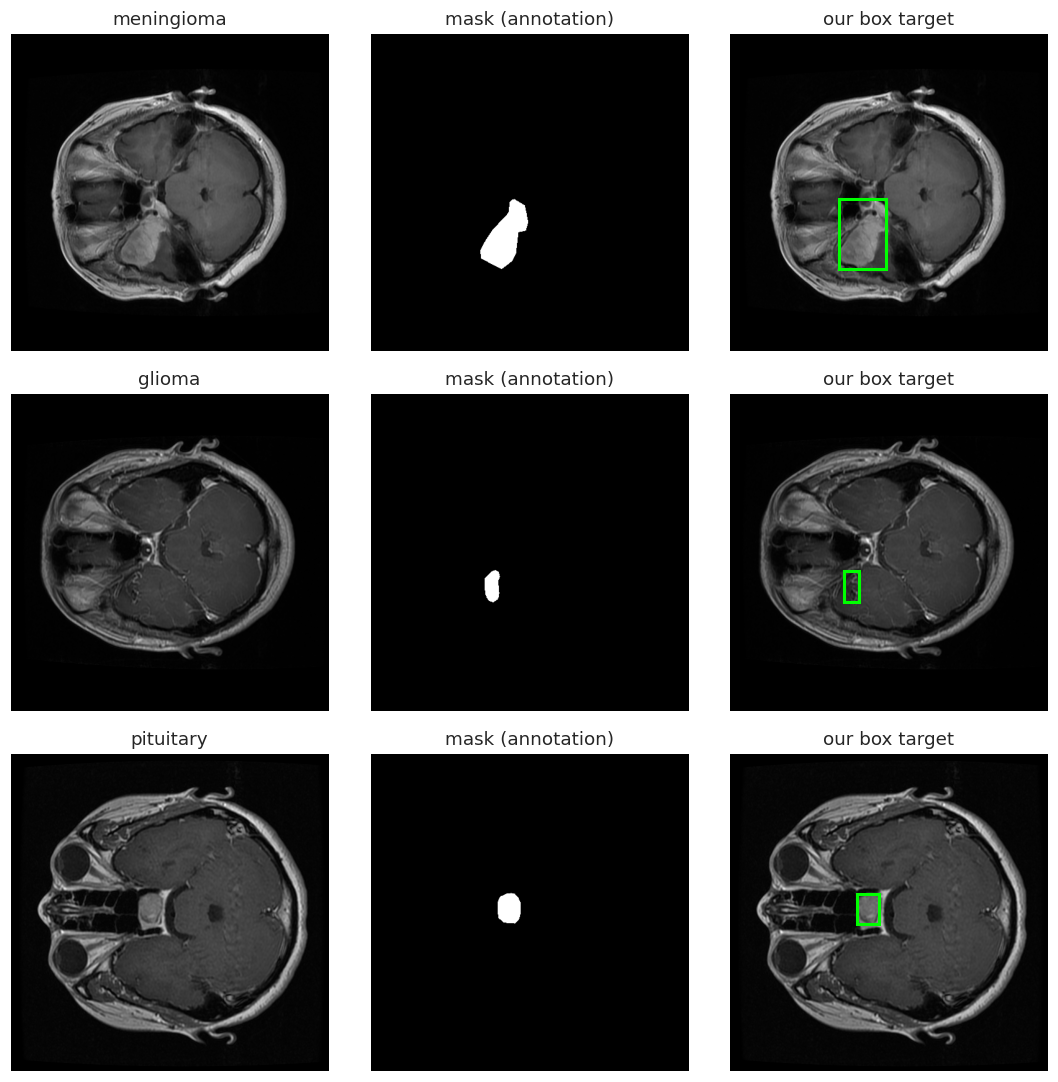

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for r, cls in enumerate(["meningioma", "glioma", "pituitary"]):
    row = df[df["label_name"] == cls].iloc[0]
    with h5py.File(row["path"], "r") as f:
        img = np.array(f["cjdata"]["image"]).astype(np.float32)
        mask = np.array(f["cjdata"]["tumorMask"]).astype(np.uint8)
    H, W = mask.shape
    axes[r, 0].imshow(img, cmap="gray"); axes[r, 0].set_title(cls)
    axes[r, 1].imshow(mask, cmap="gray"); axes[r, 1].set_title("mask (annotation)")
    axes[r, 2].imshow(img, cmap="gray")
    axes[r, 2].add_patch(plt.Rectangle(((row.cx - row.bw / 2) * W, (row.cy - row.bh / 2) * H),
                                       row.bw * W, row.bh * H, fill=False, ec="lime", lw=2))
    axes[r, 2].set_title("our box target")
    for c in range(3):
        axes[r, c].axis("off")
plt.tight_layout(); plt.show()

The green boxes sit tightly around the white mask regions, so `mask_to_box` is doing the right
thing.

Something else is visible here that turns out to matter a lot later. The three types sit in
characteristically different places - pituitary tumours are central and low, at the base of the
brain; meningiomas sit at the edge against the skull; gliomas are scattered through the tissue. So
position carries information about the class. We come back to this in Part 6.

Some EDA on the class balance and the box targets.

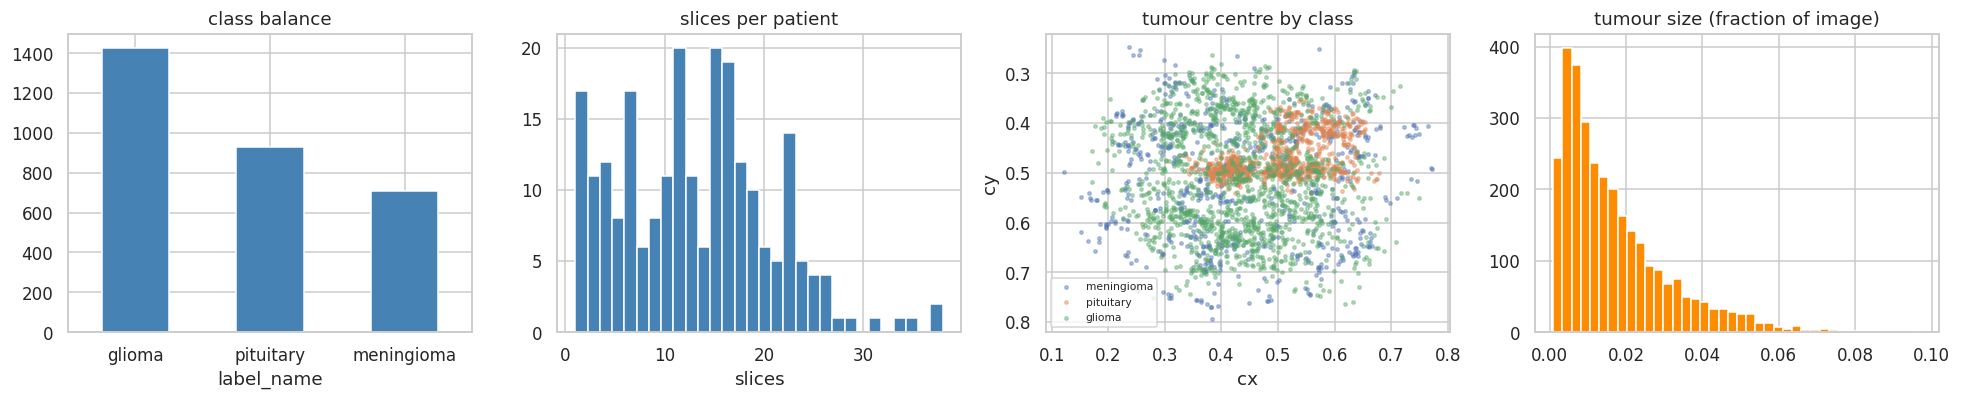

               cx     cy     bw     bh
label_name                            
glioma      0.430  0.514  0.172  0.172
meningioma  0.436  0.516  0.145  0.147
pituitary   0.503  0.467  0.098  0.101


In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
df["label_name"].value_counts().plot(kind="bar", ax=ax[0], color="steelblue", rot=0)
ax[0].set_title("class balance")

df.groupby("pid").size().hist(bins=30, ax=ax[1], color="steelblue")
ax[1].set_xlabel("slices"); ax[1].set_title("slices per patient")

for cls in df["label_name"].unique():
    s = df[df["label_name"] == cls]
    ax[2].scatter(s["cx"], s["cy"], s=5, alpha=0.4, label=cls)
ax[2].invert_yaxis(); ax[2].legend(fontsize=7); ax[2].set_title("tumour centre by class")
ax[2].set_xlabel("cx"); ax[2].set_ylabel("cy")

df["area_frac"].hist(bins=40, ax=ax[3], color="darkorange")
ax[3].set_title("tumour size (fraction of image)")
plt.tight_layout(); plt.show()

print(df.groupby("label_name")[["cx", "cy", "bw", "bh"]].mean().round(3).to_string())

Glioma is about half the data, so accuracy alone will be misleading later - a model that always
guessed glioma would be right 47% of the time. From Part 6 onwards we report macro-averaged F1,
which weights all three classes equally.

The slices-per-patient histogram is why we cannot use a normal random split. With ~13 slices per
patient, consecutive slices are nearly the same image. Split randomly and near-copies land in both
train and test, and every score comes out too high.

The centre scatter confirms what we saw in the images - pituitary tumours cluster in a tight low
central group, the other two spread more widely.

So we split by patient: 80% of the 233 patients go to train, the rest to test, and all of a
patient's slices go with them.

In [ ]:
rng = np.random.RandomState(SEED)
pids = df["pid"].unique().copy()
rng.shuffle(pids)
train_pids = set(pids[:int(len(pids) * CONFIG["TRAIN_FRAC"])])
df["split"] = np.where(df["pid"].isin(train_pids), "train", "test")

print(df["split"].value_counts().to_string())
print("\npatients:", df.groupby("split")["pid"].nunique().to_dict())
print("\nclass mix per split:")
print(pd.crosstab(df["split"], df["label_name"], normalize="index").round(3).to_string())

split
train    2393
test      671

patients: {'test': 47, 'train': 186}

class mix per split:
label_name  glioma  meningioma  pituitary
split                                    
test         0.514       0.279      0.207
train        0.452       0.218      0.331


2393 training slices and 671 test slices - not exactly 80/20 because patients contribute unequal
numbers of slices, which is expected. The class mix stays close between the two splits, so the test
set is measuring the same problem the model trained on.

This split is fixed now and every model in the notebook uses it.

---
# Part 2 - Preprocessing and features

Normalise intensity to 0-255 (different scanners produce different ranges), a light 3x3 blur to
kill noise, and resize to 128x128 so every image gives the same number of features. The blur is
deliberately small - a wide one would smooth away the texture we are about to measure.

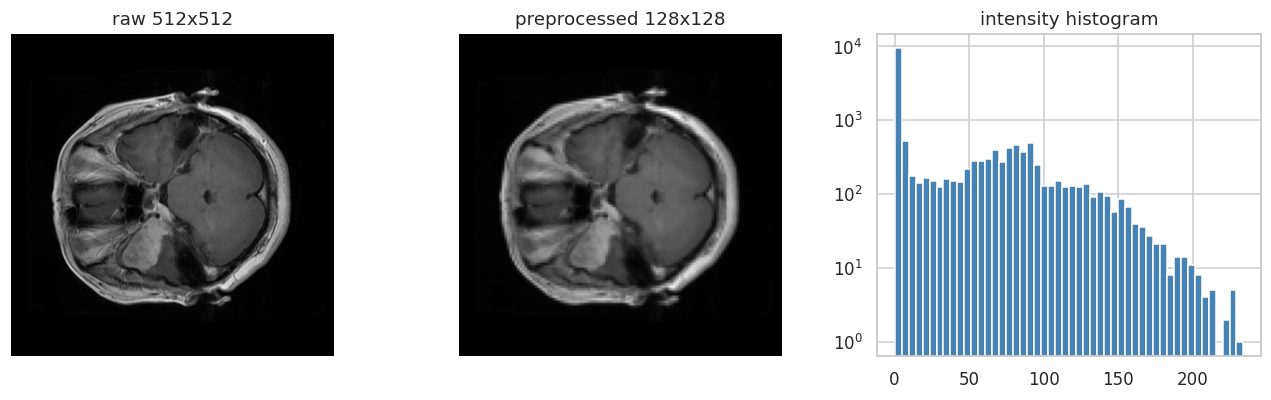

In [ ]:
IMG_SIZE = CONFIG["IMG_SIZE"]

def preprocess(raw):
    img = cv2.normalize(raw, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

with h5py.File(df.iloc[0]["path"], "r") as f:
    raw = np.array(f["cjdata"]["image"]).astype(np.float32)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
ax[0].imshow(raw, cmap="gray"); ax[0].set_title("raw 512x512"); ax[0].axis("off")
ax[1].imshow(preprocess(raw), cmap="gray"); ax[1].set_title("preprocessed 128x128"); ax[1].axis("off")
ax[2].hist(preprocess(raw).ravel(), bins=50, color="steelblue"); ax[2].set_yscale("log")
ax[2].set_title("intensity histogram")
plt.tight_layout(); plt.show()

The preprocessed image looks the same as the raw one, which is what we want. The histogram has a
big spike at 0 (black background outside the head) and a bright tail on the right - that tail is
contrast-enhanced tumour tissue, and we build a feature to exploit it in a moment.

We build **two separate sets of features**, and keeping them apart is the most important design
decision in the notebook.

**Bank A - global appearance (16 features).** GLCM texture (contrast, correlation, energy,
homogeneity, dissimilarity, ASM, averaged over 2 distances and 4 angles), intensity statistics
(mean, variance, skew, kurtosis, 3 percentiles), and edge statistics (Sobel mean/std, Laplacian
variance).

Every one of these pools over the whole image. That means they describe *what the image looks like*
and carry no information about *where* anything is - move the tumour and they barely change. We
prove that in Part 4.4 rather than just claiming it.

In [ ]:
GLCM_PROPS = ["contrast", "correlation", "energy", "homogeneity", "dissimilarity", "ASM"]

def extract_global(img):
    q = (img // 4).astype(np.uint8)          # quantise to 64 grey levels for speed
    glcm = graycomatrix(q, distances=[1, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=64, symmetric=True, normed=True)
    f = {"glcm_" + p: float(graycoprops(glcm, p).mean()) for p in GLCM_PROPS}

    x = img.astype(np.float32) / 255.0
    v = x.ravel()
    f["int_mean"] = float(v.mean())
    f["int_var"] = float(v.var())
    f["int_skew"] = float(skew(v))
    f["int_kurt"] = float(kurtosis(v))
    f["int_p10"], f["int_p50"], f["int_p90"] = [float(np.percentile(v, p)) for p in (10, 50, 90)]

    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    f["grad_mean"], f["grad_std"] = float(mag.mean()), float(mag.std())
    f["lap_var"] = float(cv2.Laplacian(img, cv2.CV_64F).var())
    return f

print(len(extract_global(preprocess(raw))), "global features")

16 global features


**Bank B - spatial grid (196 features).** Cut the image into an 8x8 grid of 16x16 cells and
describe each cell separately: mean intensity, standard deviation, and the fraction of pixels above
the image's 95th percentile. Plus the centroid and spread of all the bright pixels.

The bright-fraction feature is the one aimed at our problem. These are contrast-enhanced scans, so
tumour tissue lights up, and "which cells have unusually many bright pixels" is a crude tumour
detector. Crucially it is position-aware, because there is one value per cell.

8x8x3 + 4 = 196 features. Neighbouring cells will be correlated, and 196 features is a lot - both
of which become the point of Part 5.

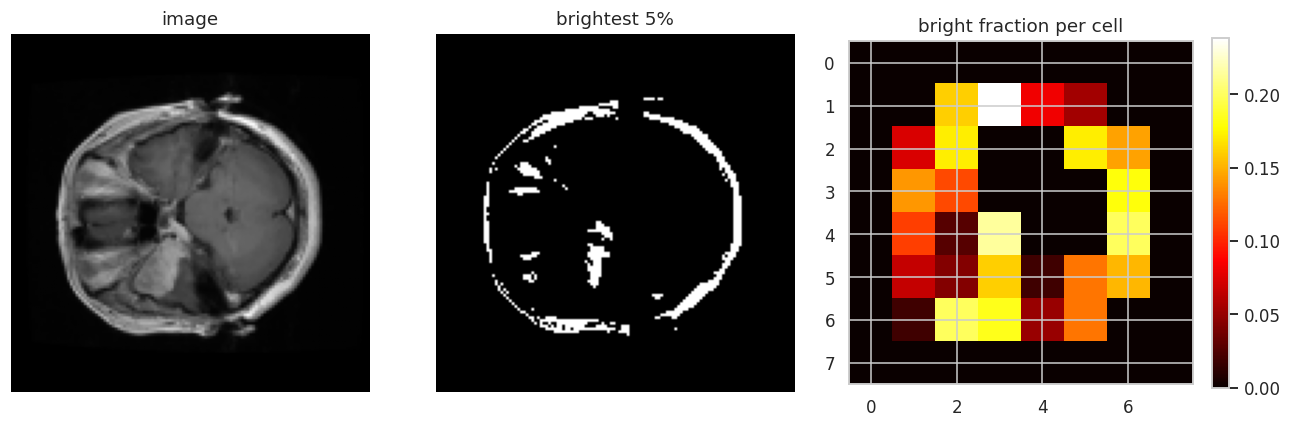

196 grid features


In [ ]:
GRID = CONFIG["GRID"]

def extract_grid(img, grid=GRID, pctl=CONFIG["BRIGHT_PCTL"]):
    x = img.astype(np.float32) / 255.0
    bright = (x >= np.percentile(x, pctl)).astype(np.float32)
    cell = x.shape[0] // grid
    f = {}
    for r in range(grid):
        for c in range(grid):
            b = x[r*cell:(r+1)*cell, c*cell:(c+1)*cell]
            bb = bright[r*cell:(r+1)*cell, c*cell:(c+1)*cell]
            f["g%d%d_mean" % (r, c)] = float(b.mean())
            f["g%d%d_std" % (r, c)] = float(b.std())
            f["g%d%d_bright" % (r, c)] = float(bb.mean())
    ys, xs = np.nonzero(bright)
    H, W = x.shape
    f["bright_cx"], f["bright_cy"] = float(xs.mean() / W), float(ys.mean() / H)
    f["bright_sx"], f["bright_sy"] = float(xs.std() / W), float(ys.std() / H)
    return f

img0 = preprocess(raw)
g = extract_grid(img0)
gm = np.array([[g["g%d%d_bright" % (r, c)] for c in range(GRID)] for r in range(GRID)])

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
ax[0].imshow(img0, cmap="gray"); ax[0].set_title("image"); ax[0].axis("off")
ax[1].imshow(img0 >= np.percentile(img0, 95), cmap="gray"); ax[1].set_title("brightest 5%"); ax[1].axis("off")
im = ax[2].imshow(gm, cmap="hot"); ax[2].set_title("bright fraction per cell")
plt.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()
print(len(g), "grid features")

The bright mask picks up the tumour, but it also picks up skull, fat and other enhancing tissue -
so this feature finds bright things, and a tumour is only one kind of bright thing. That is its
honest limitation.

Run both extractors over all 3064 images. We also keep the preprocessed images in one array so the
CNN in Part 10 does not have to reopen 3064 HDF5 files. Cached, so this is slow once (about 80
seconds) and instant afterwards.

In [ ]:
if os.path.exists("cache/features.csv"):
    feat_df = pd.read_csv("cache/features.csv")
    X_img = np.load("cache/images.npy")
else:
    rows, imgs = [], np.zeros((len(df), IMG_SIZE, IMG_SIZE), np.uint8)
    t0 = time.time()
    for i, r in enumerate(df.itertuples(index=False)):
        with h5py.File(r.path, "r") as f:
            img = preprocess(np.array(f["cjdata"]["image"]).astype(np.float32))
        imgs[i] = img
        d = extract_global(img)
        d.update(extract_grid(img))
        rows.append(d)
        if (i + 1) % 1000 == 0:
            print(" ", i + 1, "/", len(df), "%.0fs" % (time.time() - t0))
    feat_df, X_img = pd.DataFrame(rows), imgs
    feat_df.to_csv("cache/features.csv", index=False)
    np.save("cache/images.npy", X_img)

GLOBAL_COLS = [c for c in feat_df.columns if c.startswith(("glcm_", "int_", "grad_", "lap_"))]
GRID_COLS = [c for c in feat_df.columns if c not in GLOBAL_COLS]
ALL_COLS = GLOBAL_COLS + GRID_COLS

data = pd.concat([feat_df, df[["label", "label_name", "pid", "split",
                               "cx", "cy", "bw", "bh", "area_frac"]]], axis=1)

print("images:", X_img.shape)
print("features: %d global + %d grid = %d, on %d rows"
      % (len(GLOBAL_COLS), len(GRID_COLS), len(ALL_COLS), len(data)))
print("missing values:", data[ALL_COLS].isna().sum().sum())

  1000 / 3064 33s
  2000 / 3064 50s
  3000 / 3064 66s
images: (3064, 128, 128)
features: 16 global + 196 grid = 212, on 3064 rows
missing values: 0


212 features, 3064 rows, no missing values - unsurprising, since every feature is computed rather
than collected.

We are **not** capping outliers. Our first version of this project IQR-capped everything including
the regression target, which quietly squashed the top of the target range and made the problem
easier than reality. The box targets are already bounded in [0,1] by construction, and the extreme
feature values are real measurements from real scans. If outliers turn out to be a problem, RANSAC
in Part 4.7 will tell us.

The feature scales are wildly different (`glcm_contrast` in the hundreds, `int_var` around 0.02).
Plain linear regression does not care, but anything distance-based or penalised does, so we
standardise inside pipelines from Part 5 onward.